<div style="border-left:6px solid #7E22CE;background:#4F46E5;color:#fff;padding:16px 20px;border-radius:4px">
<code style="background:transparent;color:#C7D2FE">INF672 &nbsp;/&nbsp; Unidad 2 &nbsp;/&nbsp; <b style="color:#fff">2.1.3</b></code><br>
<span style="color:#DDD6FE;font-size:0.8em;letter-spacing:1px"><b>REPASO MATEMÁTICO ORIENTADO AL MACHINE LEARNING</b></span>
<h1 style="color:#fff;margin:6px 0">Estadística descriptiva</h1>
<i style="color:#EDE9FE">Cuaderno de práctica — describir los datos antes de modelarlos</i>
</div>

**Materia:** Machine Learning (INF672) · Ingeniería Informática · UATF &nbsp;|&nbsp; **Docente:** M. Sc. Huáscar F. Gonzales G. &nbsp;|&nbsp; **Gestión:** 2026-02

Este cuaderno acompaña al documento teórico del tema 2.1.3. Es un **repaso**: la teoría completa la ves en tu materia de Probabilidad y Estadística. Aquí reactivamos solo lo que el Machine Learning usa, calculándolo con **NumPy** y **Pandas** sobre el dataset `iris`. Ejecuta las celdas en orden (`Shift + Enter`).

## 0 · Preparación del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# --- paleta INF672 (para que los gráficos combinen con el documento) ---
INDIGO, PURPLE, CORAL, INK, GREY = "#4F46E5", "#7E22CE", "#F43F5E", "#111827", "#6B7280"
plt.rcParams.update({
    "axes.edgecolor": "#D1D5DB", "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.grid": True, "grid.color": "#E5E7EB", "grid.linewidth": 0.7, "axes.axisbelow": True,
    "figure.dpi": 110,
})

iris = load_iris()
df = pd.DataFrame(iris.data, columns=["sep_largo", "sep_ancho", "pet_largo", "pet_ancho"])
print("Forma del dataset:", df.shape)
df.head()

Forma del dataset: (150, 4)


,sep_largo,sep_ancho,pet_largo,pet_ancho
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 1 · Tendencia central: media, mediana y moda

¿Dónde está el centro de los datos?

- **Media** $\bar{x} = \dfrac{1}{n}\sum_{i} x_i$ — el promedio aritmético.
- **Mediana** — el valor central al ordenar los datos.
- **Moda** — el valor que más se repite.

In [11]:
col = df["pet_largo"]
print("media   :", round(col.mean(), 3))
print("mediana :", round(col.median(), 3))
print("moda    :", col.mode().tolist())   # la moda es más útil en variables discretas/categóricas

media   : 3.758
mediana : 4.35
moda    : [1.4, 1.5]


La media (3.76) y la mediana (4.35) **no coinciden**: los datos no son simétricos. Hay un grupo de flores muy pequeñas (la especie *setosa*) que jala la media hacia abajo.

### La idea que importa: la mediana es robusta
Inyectamos un valor absurdo y vemos qué le pasa a cada medida.

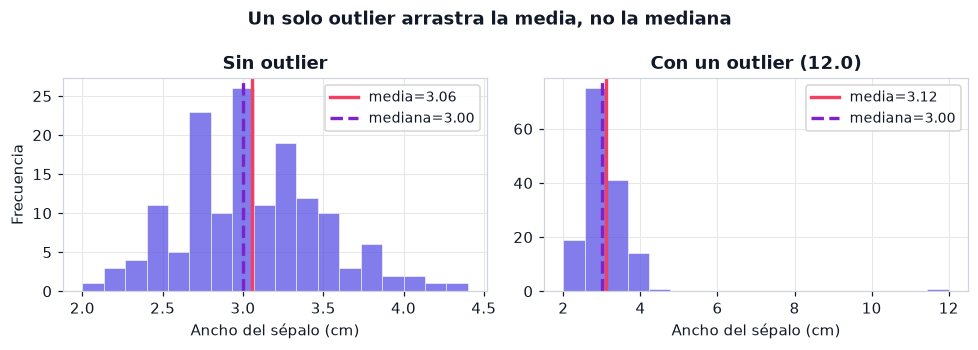

In [12]:
base = df["sep_ancho"].values
conout = np.append(base, 12.0)          # un ancho de sépalo imposible

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, data, titulo in [(axes[0], base, "Sin outlier"),
                         (axes[1], conout, "Con un outlier (12.0)")]:
    ax.hist(data, bins=18, color=INDIGO, alpha=0.7, edgecolor="white", linewidth=0.5)
    ax.axvline(data.mean(),   color=CORAL,  lw=2.2, label=f"media={data.mean():.2f}")
    ax.axvline(np.median(data), color=PURPLE, lw=2.2, ls="--", label=f"mediana={np.median(data):.2f}")
    ax.set_title(titulo); ax.set_xlabel("Ancho del sépalo (cm)"); ax.legend(fontsize=9)
axes[0].set_ylabel("Frecuencia")
fig.suptitle("Un solo outlier arrastra la media, no la mediana", fontweight="bold")
plt.tight_layout(); plt.show()

> **🟣 Conexión ML** — Cuando en el preprocesamiento tengas que rellenar valores faltantes (tema 2.3.1), elegirás media o mediana según haya *outliers*: la **mediana es la opción segura**. La misma robustez es la base de varias técnicas de detección de anomalías.

## 2 · Dispersión: varianza y desviación estándar

$$\sigma^2 = \frac{1}{n}\sum_i (x_i - \bar{x})^2 \qquad\qquad \sigma = \sqrt{\sigma^2}$$

La **varianza** promedia las distancias al cuadrado respecto a la media; la **desviación estándar** ($\sigma$) es su raíz, y vuelve a las unidades originales (cm), así que es la que se interpreta.

In [4]:
print("varianza :", round(col.var(ddof=0), 3))
print("desv. σ  :", round(col.std(ddof=0), 3))

# Resumen de las cuatro características a la vez:
resumen = pd.DataFrame({
    "media":   df.mean().round(2),
    "mediana": df.median().round(2),
    "desv_σ":  df.std(ddof=0).round(2),
    "min":     df.min().round(2),
    "max":     df.max().round(2),
})
resumen

varianza : 3.096
desv. σ  : 1.759


,media,mediana,desv_σ,min,max
sep_largo,5.84,5.80,0.83,4.3,7.9
sep_ancho,3.06,3.00,0.43,2.0,4.4
pet_largo,3.76,4.35,1.76,1.0,6.9
pet_ancho,1.20,1.30,0.76,0.1,2.5


> **⚪ Nota — el `ddof`** &nbsp; `np.var` / `np.std` dividen entre $n$ (varianza *poblacional*). Pandas divide entre $n-1$ (`ddof=1`, varianza *muestral*). La diferencia es mínima con 150 datos; solo conviene saber que existe.

El `pet_largo` se esparce mucho más ($\sigma \approx 1.76$) que el `sep_ancho` ($\sigma \approx 0.44$). Los cuartiles, el rango intercuartílico y el *boxplot* dan otras miradas a la dispersión, pero pertenecen más a tu materia de estadística.

> **🟣 Conexión ML** — Cuando las características viven en escalas muy distintas, los modelos basados en distancia (KNN, K-means) y en gradiente se dejan dominar por la de mayor dispersión. Medir la dispersión es el primer paso hacia el **escalado de características** (tema 2.3.3).

## 3 · La forma de la distribución: leer un histograma

Media y desviación resumen los datos en dos números pero **pierden la forma**. El histograma la recupera: revela el centro, la dispersión, si hay sesgo y cuántos *picos* (modas) tiene.

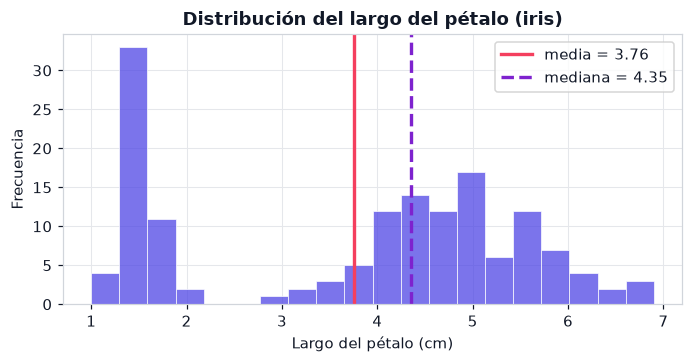

In [5]:
pl = df["pet_largo"].values
plt.figure(figsize=(6.4, 3.4))
plt.hist(pl, bins=20, color=INDIGO, alpha=0.75, edgecolor="white", linewidth=0.6)
plt.axvline(pl.mean(),   color=CORAL,  lw=2.2, label=f"media = {pl.mean():.2f}")
plt.axvline(np.median(pl), color=PURPLE, lw=2.2, ls="--", label=f"mediana = {np.median(pl):.2f}")
plt.xlabel("Largo del pétalo (cm)"); plt.ylabel("Frecuencia")
plt.title("Distribución del largo del pétalo (iris)"); plt.legend()
plt.tight_layout(); plt.show()

Este histograma es **bimodal**: el grupo de la izquierda son las flores *setosa*, separadas del resto. Ese hueco explica por qué la media caía donde casi no hay datos: cuando la distribución no es unimodal ni simétrica, la media sola engaña.

> **🟣 Conexión ML** — Una característica bimodal probablemente **separa bien las clases**; un sesgo fuerte sugiere transformar la variable; una cola larga delata *outliers*. Es la puerta de entrada a la distribución Normal (parte de probabilidad).

## 4 · Relación entre dos variables: correlación

La **covarianza** dice si dos variables crecen juntas, pero su magnitud depende de las unidades. La **correlación de Pearson** la normaliza al rango $[-1, +1]$:

$$+1 = \text{relación lineal positiva perfecta}, \quad 0 = \text{sin relación lineal}, \quad -1 = \text{negativa perfecta}.$$

In [6]:
df.corr().round(2)

,sep_largo,sep_ancho,pet_largo,pet_ancho
sep_largo,1.00,-0.12,0.87,0.82
sep_ancho,-0.12,1.00,-0.43,-0.37
pet_largo,0.87,-0.43,1.00,0.96
pet_ancho,0.82,-0.37,0.96,1.00


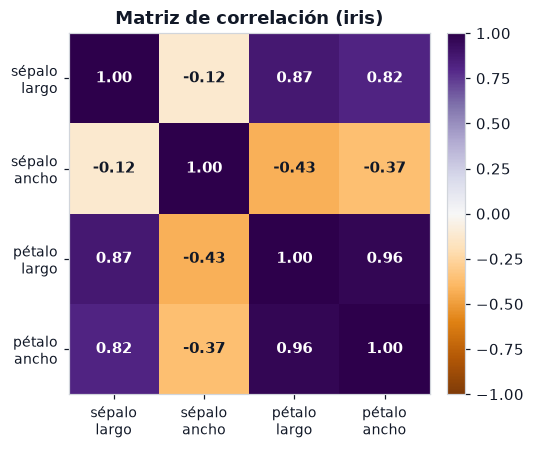

In [7]:
# Mapa de calor de la matriz de correlación
C = df.corr().values
labels = ["sépalo\nlargo", "sépalo\nancho", "pétalo\nlargo", "pétalo\nancho"]
fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(C, cmap="PuOr", vmin=-1, vmax=1)
ax.set_xticks(range(4), labels, fontsize=9); ax.set_yticks(range(4), labels, fontsize=9)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{C[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(C[i,j]) > 0.55 else INK, fontweight="bold")
ax.set_title("Matriz de correlación (iris)"); ax.grid(False)
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

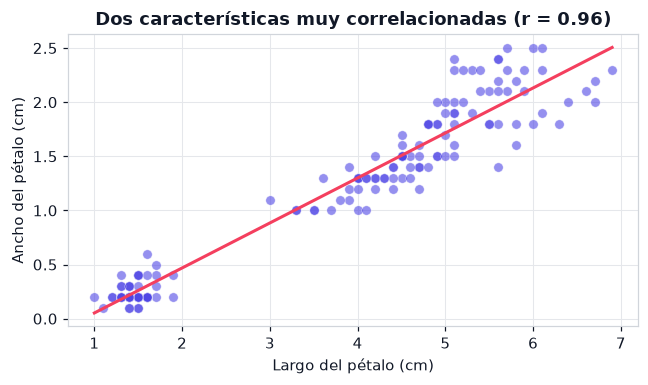

In [16]:
# El par más correlacionado: largo vs ancho del pétalo
x, y = df["pet_largo"].values, df["pet_ancho"].values
r = np.corrcoef(x, y)[0, 1]
b1, b0 = np.polyfit(x, y, 1)
plt.figure(figsize=(6, 3.6))
plt.scatter(x, y, color=INDIGO, alpha=0.6, edgecolor="white", linewidth=0.4, s=38)
plt.plot([x.min(), x.max()], b0 + b1*np.array([x.min(), x.max()]), color=CORAL, lw=2)
plt.xlabel("Largo del pétalo (cm)"); plt.ylabel("Ancho del pétalo (cm)")
plt.title(f"Dos características muy correlacionadas (r = {r:.2f})")
plt.tight_layout(); plt.show()

### El puente con el álgebra lineal (tema 2.1.1)

La correlación de Pearson es **exactamente el coseno del ángulo entre los vectores centrados** (a cada variable se le resta su media):

$$\operatorname{corr}(x, y) = \cos(x-\bar{x},\, y-\bar{y}) = \frac{(x-\bar{x}) \cdot (y-\bar{y})}{\lVert x-\bar{x}\rVert \; \lVert y-\bar{y}\rVert}$$

Es la misma similitud coseno del producto punto que viste en álgebra lineal. Compruébalo:

In [9]:
xc, yc = x - x.mean(), y - y.mean()
cos = xc @ yc / (np.linalg.norm(xc) * np.linalg.norm(yc))
print("Pearson (np.corrcoef) :", round(np.corrcoef(x, y)[0, 1], 6))
print("coseno centrado       :", round(float(cos), 6))
print("¿idénticos? ->", np.isclose(np.corrcoef(x, y)[0, 1], cos))

Pearson (np.corrcoef) : 0.962865
coseno centrado       : 0.962865
¿idénticos? -> True


> **🟣 Conexión ML** — Dos características muy correlacionadas (aquí 0.96) cargan casi la misma información: una es casi **redundante**. Detectarlo guía la **selección de características** (tema 2.4) y previene problemas en modelos lineales.

## 5 · Síntesis y fronteras

| Concepto | En NumPy / Pandas | Para qué en ML |
|---|---|---|
| Media / mediana | `.mean()` / `.median()` | Imputar faltantes (2.3.1); la mediana es robusta |
| Varianza / desviación | `.var()` / `.std()` | Ver escalas → escalado (2.3.3) |
| Histograma | `plt.hist(...)` | Intuición de forma; separar clases |
| Correlación | `df.corr()` | Redundancia → selección (2.4); puente al coseno |

**Queda fuera a propósito de este tema:** cuartiles/IQR y *boxplot* a fondo y la fórmula de la covarianza (tu materia de estadística) · el *z-score* como escalado (tema 2.3.3) · la visualización a fondo con Matplotlib (tema 2.2.3) · la estadística inferencial (tests, p-valores, intervalos de confianza).

---
*Fin del cuaderno · INF672 / Unidad 2 / 2.1.3 — Estadística descriptiva*